### **3.3 Exploring Random Walks and Stationarity**

In this practical you will explore the concept of a **random walk**, a foundational idea in time series analysis and financial modelling. The activity is divided into four parts to help you build a strong understanding through simulation and real data analysis.

- **Part 1**: Understanding Stationary vs Non_Stationary Processes.

You will begin by simulating and visualising two time series: one **stationary** and one **non-stationary**.

- **Part 2**: Simulating a Random Walk.

Next, you will simulate a **random walk** in Python - a type of non-stationary process where each value depends on the previous one plus random noise.

- **Part 3**: Predicting a Random Walk.

In this section you will attempt to make naive forecasts of a random walk and evaluate how predictable (or unpredictable) it really is.

- **Part 4**: Analysing Real Data (Google Stock Prices)

Finally, you will load **Alphabet's (Google) historical stock prices** and assess whether the time series behaves like a random walk.

---

This activity will help you:

- Understand the differences between **stationary** and **non-stationary** time series

- Simulate and analyse a **random walk**

- Evaluate the **predictability** of a random walk

- Apply your understanding to a real-world dataset

**Required file:** `GOOGL.csv`

---

This activity has been adapted from [this book](https://www.manning.com/books/time-series-forecasting-in-python-book)

**Preparation: Load the Libraries**

To begin, we will load the libraries required for time series analysis and visualisation. These include:

- `pandas` amd `numpy` for data handling

- `matplotlib` for plotting

- `statsmodels` for time series decomposition, autocorrelation plots, and stationarity testing

We have also included a warning suppression line to keep the output clean, and `%matplotlib inline` to display plots within the norebook.

In [1]:
# Time series tools from the statsmodels library
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf

# Data manipulation
import pandas as pd
import numpy as np

# Plotting library
%matplotlib inline
import matplotlib.pyplot as plt

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

#### **Part 1: Understanding Stationary vs Non-Stationary Processes**

A **stationary process** is one whose key statistical properties - **mean**, **variance**, and **autocorrelation** - remain **constant over time**. Many time series models, such as ARIMA, assume the input data is stationary to produce reliable forecasts.

We can represent a simple time series process using the equation:

$$y_t=C+\alpha_1y_{t-1}+\epsilon_t$$

Where:

- $C$ is a constant
- $\alpha_{1}$ is the **root** of the process
- $\epsilon_{t}$ is random error (white noise)

The **staionarity** of this process depends on the value of $\alpha_{1}$:

- If $\alpha_{1}$ **is between -1 and 1**, the process is **stationary**
- If $\alpha_{1}=1$ (also known as unit root), the process is **non-stationary**

**1.1 Simulating Stationary and Non-Stationary Processes**

To better understand stationarity, we will simulate two different time series:

- One with a **stationary process**, where the autoregressive root $\alpha=0.5$
- One with a **non-stationary process**, where $\alpha=1$, resulting in a unit root

This will allow us to **visualise the difference** between a stationary and a non-stationary series.

In [2]:
# Let's simulate the process of testing stationarity
def simulate_process(is_stationary: bool) -> np.array:
    np.random.seed(42)
    process = np.empty(400)

    # Assuming that the root unit (alpha) is 0.5
    if is_stationary:
        alpha = 0.5
        process[0] = 0
    else:
        # Assuming the root unit (alpha) is 1
        alpha = 1
        process[0] = 10

    for i in range(400):
        if i + 1 < 400:
            process[i + 1] = alpha * process[i] + np.random.normal()
        else:
            break
    return process

In [3]:
# Simulate the stationary and non-stationary
stationary_process = simulate_process(is_stationary=True)
non_stationary_process = simulate_process(is_stationary=False)

The following plot below shows the difference between a **stationary** and a **non-stationary** process:

- The **stationary series** (solid line) fluctuates around a constant mean with a stable variance.
- The **non-stationary series** (dashed line) shows a drifting pattern, with values that wander further from the starting point over time.

This visual comparison helps highlight why testing for stationarity is an important step in time series analysis.

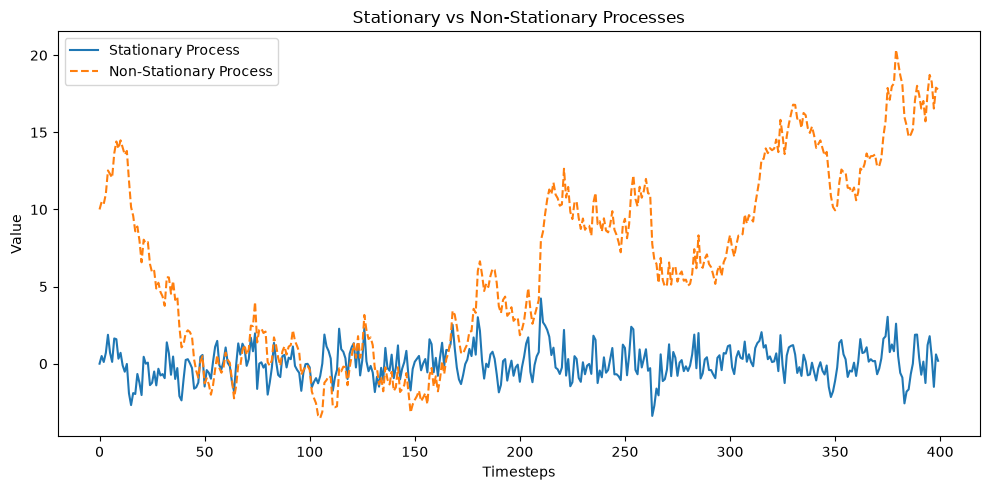

In [5]:
# Plotting the stationary and non-stationary processes
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(stationary_process, linestyle='-', label='Stationary Process')
ax.plot(non_stationary_process, linestyle='--', label='Non-Stationary Process')
ax.legend(loc=2)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
plt.title("Stationary vs Non-Stationary Processes")
plt.tight_layout()
plt.show()

By looking at the two series, you can get an idea of how **stationary** and **non-stationary** processes behave over time.

Notice that the **stationary process** does not show a long-term increase or decrease - it fluctuates around a constant level. This is because **stationary series have constant statistical properties**, such as **mean** and **variance**, that remain stable over time.

In contrast, the **non-stationary process** tends to drift and does not return to a fixed level, indicating that its properties change over time.

**1.2 Mean and Variance of the simulated processes**

The following code can be used for computing the **cumulative mean** at each time point for both processes.

In [6]:
def mean_over_time(process: np.array) -> np.array:
    mean_func = []

    for i in range(1, len(process) + 1):
        mean_func.append(np.mean(process[:i]))

    return np.array(mean_func)

In [7]:
# Compute for stationary mean and non-stationary mean over time
stationary_mean = mean_over_time(stationary_process)
non_stationary_mean = mean_over_time(non_stationary_process)

The plot below shows the **cumulative mean** for the stationary and non-stationary processes.

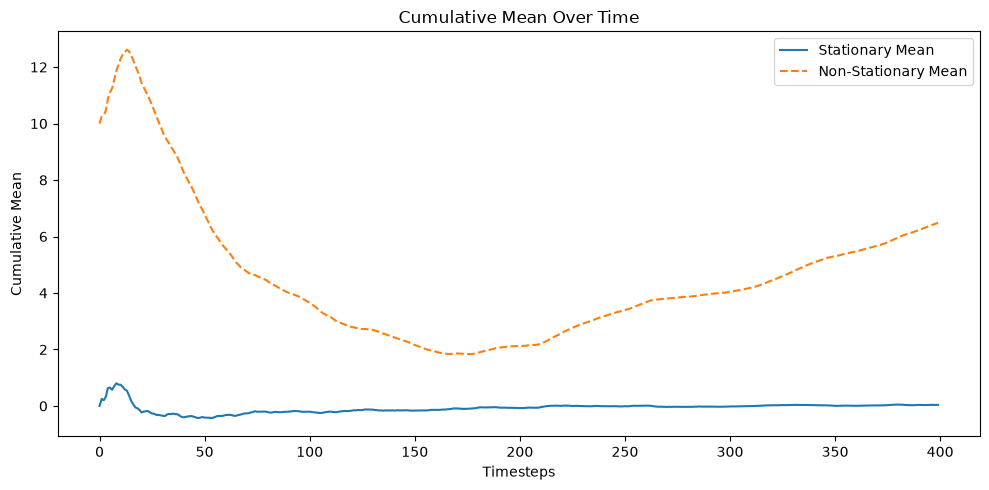

In [10]:
# Plot the cumulative mean over time for both processes
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(stationary_mean, linestyle='-', label='Stationary Mean')
ax.plot(non_stationary_mean, linestyle='--', label='Non-Stationary Mean')
ax.legend(loc=1)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Cumulative Mean")
plt.title("Cumulative Mean Over Time")
plt.tight_layout()
plt.show()

Now we can perform a similar process to track how the **variance** changes over time for each series.

In [11]:
def var_over_time(process: np.array) -> np.array:
    var_func = []

    for i in range(1, len(process) + 1):
        var_func.append(np.var(process[:i]))

    return np.array(var_func)

In [12]:
# Variance over time for both processes
stationary_variance = var_over_time(stationary_process)
non_stationary_variance = var_over_time(non_stationary_process)

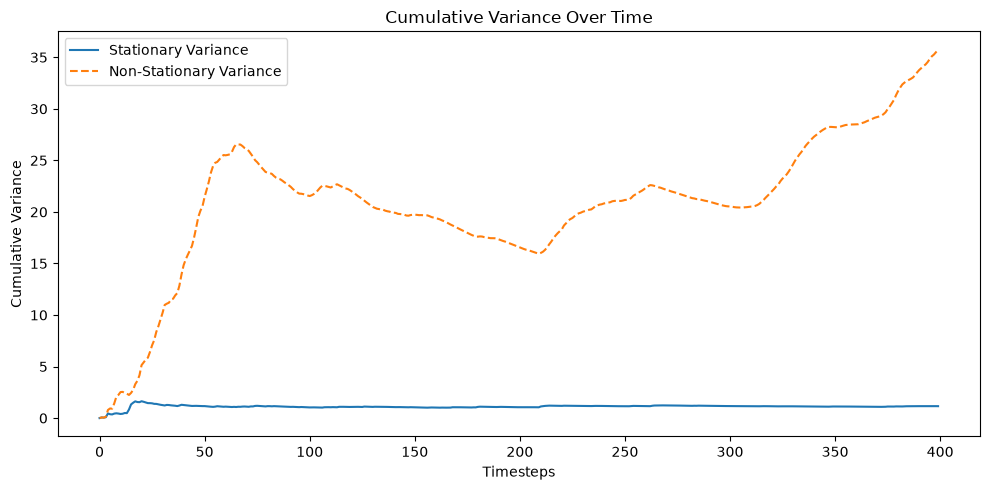

In [14]:
# Plot the cumulative variance over time for both processes
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(stationary_variance, linestyle='-', label='Stationary Variance')
ax.plot(non_stationary_variance, linestyle='--', label='Non-Stationary Variance')
ax.legend(loc=2)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Cumulative Variance")
plt.title("Cumulative Variance Over Time")
plt.tight_layout()
plt.show()

The plot clearly shows the difference between stationary and non-stationary processes.

- In the **stationary** series, both the mean and variance **stabilise quickly and remain relatively constant**.
- In contrast, the **non-stationary** series shows a **drifting mean** and **increasing variance**, which are signs that its statistical properties are changing over time.

**1.3 Testing for stationarity**

Before we can apply most time series forecasting models, we need to verify whether the data is **stationary**.

To do this, we use the **Augmented Dickey-Fuller (ADF) test**, a statistical test designed to detect the presence of a **unit root**.

- **Null hypothesis ($H_{0}$)**: The time series has a **unit root** → it is **non-stationary**
- **Alternative hypothesis ($H_{1}$)**: The time series has **no unit root** → it is **stationary**

If the **p-value** from the test is **less than 0.05**, we can reject the null hypothesis and conclude that the time series is likely stationary.

We will apply the ADF test to both our **simulated stationary** and **non-stationary** series to confirm the differences statistically.